In [4]:
import os
import sys

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

from utility import plot

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [5]:
SEED = 42
PLOT_DPI = 100

# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_fe_train.csv"
# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_smote_fe.csv"
# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_adasyn_fe.csv"
# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_cwgan_fe.csv"
TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_cwgan_reg_fe.csv"

TEST_DATA_FILE = "../data/preprocessed_skab_dataset_fe_test.csv"

USE_LDA = False
USE_FE = True

In [6]:
dataframe_train = pd.read_csv(TRAIN_DATA_FILE)
# dataframe_train.set_index(pd.to_datetime(dataframe_train.datetime), drop=True, inplace=True)
# dataframe_train.drop(columns=["datetime"], inplace=True)

if not USE_FE:
    og_columns = ["Accelerometer1RMS", "Accelerometer2RMS", "Current", "Pressure", "Temperature", "Thermocouple", "Voltage", "Volume Flow RateRMS", "anomaly", "description"]
    dataframe_train = dataframe_train.drop(columns=[col for col in dataframe_train.columns if col not in og_columns])

dataframe_train.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,76.492320,0.008463,...,59.9847,227.509732,574.313444,0.396142,0.822275,0.000462,0.154822,0.006604,0.0,No Anomaly
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,171.550171,0.042488,...,43.8822,77.025248,299.058927,0.257559,0.670037,0.000036,0.229541,0.005869,0.0,No Anomaly
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,102.209082,0.013628,...,58.5997,366.332439,431.639079,0.848701,0.824648,0.000437,0.204520,0.014483,0.0,No Anomaly
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,77.492989,0.008531,...,57.3947,225.718316,592.311646,0.381080,0.867514,0.000597,0.145544,0.006640,0.0,No Anomaly
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,149.973738,0.009526,...,65.1049,94.131282,310.699174,0.302966,0.631739,0.000137,0.280788,0.004654,0.0,No Anomaly


In [7]:
dataframe_test = pd.read_csv(TEST_DATA_FILE)
# dataframe_test.set_index(pd.to_datetime(dataframe_test.datetime), drop=True, inplace=True)
# dataframe_test.drop(columns=["datetime"], inplace=True)

if not USE_FE:
    og_columns = ["Accelerometer1RMS", "Accelerometer2RMS", "Current", "Pressure", "Temperature", "Thermocouple", "Voltage", "Volume Flow RateRMS", "anomaly", "description"]
    dataframe_test = dataframe_test.drop(columns=[col for col in dataframe_test.columns if col not in og_columns])

dataframe_test.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,description,anomaly
0,0.210323,0.262893,2.65864,1.074847,88.6217,29.3147,230.091,126.677,86.544624,0.008485,...,59.3070,226.931105,519.969766,0.436431,0.800033,0.000436,0.170436,0.007359,No Anomaly,0.0
1,0.028297,0.042536,0.81412,0.745430,68.0318,24.2354,232.174,32.000,285.184002,0.023295,...,43.7964,39.756362,160.664872,0.247449,0.665238,0.000038,0.423439,0.005650,No Anomaly,0.0
2,0.028185,0.041387,0.81061,1.073357,68.8750,24.7075,208.422,32.000,257.117479,0.033542,...,44.1675,57.245837,143.606614,0.398630,0.681015,0.000036,0.479609,0.009025,No Anomaly,0.0
3,0.027955,0.042217,1.12593,1.073357,68.9973,24.7679,235.556,27.000,209.210164,0.039754,...,44.2294,48.301175,225.436632,0.214256,0.662168,0.000044,0.306061,0.004844,Inlet Valve Malfunction,12.0
4,0.211749,0.272061,2.65451,1.402774,90.2739,27.8473,225.678,123.668,85.016820,0.011343,...,62.4266,289.130998,509.204832,0.567809,0.778314,0.000466,0.177284,0.009096,No Anomaly,0.0


In [8]:
scaler = StandardScaler()

values = scaler.fit_transform(dataframe_train.drop(columns=["anomaly", "description"]).values)

if USE_LDA:
    lda = LinearDiscriminantAnalysis()
    values = lda.fit_transform(values, dataframe_train.anomaly.to_numpy().ravel())
    dataframe_train_scaled = pd.DataFrame(values, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, values.shape[1]+1)])
else:
    dataframe_train_scaled = pd.DataFrame(values, columns=dataframe_train.drop(columns=["anomaly", "description"]).columns)

dataframe_train_scaled = dataframe_train_scaled.assign(anomaly=dataframe_train.anomaly.values, description=dataframe_train.description.values)
dataframe_train_scaled

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,-0.168137,-0.280996,1.316481,-0.342282,0.646297,0.078486,-0.192103,0.641333,-0.728586,0.011344,...,0.733508,0.500946,1.318483,-0.082546,0.371835,0.003490,-0.813059,-0.251040,0.0,No Anomaly
1,-1.036436,-1.262395,-1.161801,2.350079,-2.069740,-1.278164,3.891130,-1.285985,0.745270,0.028759,...,-1.844065,-1.075322,-0.990941,-0.839486,0.112692,-0.006251,0.060494,-0.490503,0.0,No Anomaly
2,-0.193283,-0.313671,0.120639,5.067013,0.560825,0.321667,-0.084556,0.641333,-0.329852,0.013987,...,0.511807,1.955062,0.121425,2.389323,0.375875,0.002934,-0.232033,2.316876,0.0,No Anomaly
3,-0.005580,-0.161570,1.359386,-0.342282,0.283277,0.039654,0.930129,0.620834,-0.713071,0.011378,...,0.318919,0.482182,1.469491,-0.164813,0.448842,0.006580,-0.921537,-0.239440,0.0,No Anomaly
4,-0.793953,-0.882156,-0.954069,-3.157704,0.421743,-2.133643,1.321352,-0.383623,0.410731,0.011888,...,1.553113,-0.896143,-0.893278,-0.591473,0.047501,-0.003939,0.659645,-0.886763,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312020,-0.082789,0.335878,0.240225,-1.204288,0.089780,0.323650,0.055318,0.706617,-0.376750,0.010827,...,-0.051907,0.323172,0.252475,0.324850,-0.034285,0.010038,-0.407432,0.382071,7.0,Sharp Water Increase (Circuit)
312021,-0.198714,0.221848,0.086243,-0.911461,0.134269,0.365489,-0.135654,0.728980,-0.316121,0.010934,...,-0.019333,0.423020,0.083086,0.568308,-0.080121,0.007107,-0.293599,0.634605,7.0,Sharp Water Increase (Circuit)
312022,-0.214409,0.234336,0.081974,-0.984900,0.122268,0.334620,-0.028769,0.749325,-0.310823,0.010870,...,-0.018489,0.419886,0.086330,0.561941,-0.102451,0.006876,-0.298155,0.627443,7.0,Sharp Water Increase (Circuit)
312023,-0.158391,0.390694,0.302429,-1.162932,0.079456,0.304599,0.041231,0.734236,-0.402549,0.010808,...,-0.054872,0.357510,0.314391,0.322500,-0.131305,0.009164,-0.445378,0.380461,7.0,Sharp Water Increase (Circuit)


In [9]:
values = scaler.transform(dataframe_test.drop(columns=["anomaly", "description"]).values)

if USE_LDA:
    values = lda.transform(values)
    dataframe_test_scaled = pd.DataFrame(values, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, values.shape[1]+1)])
else:
    dataframe_test_scaled = pd.DataFrame(values, columns=dataframe_test.drop(columns=["anomaly", "description"]).columns)

dataframe_test_scaled = dataframe_test_scaled.assign(anomaly=dataframe_test.anomaly.values, description=dataframe_test.description.values)
dataframe_test_scaled

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,-0.210207,-0.299168,0.812102,-0.342282,0.606784,0.203087,0.420671,0.634712,-0.572727,0.011355,...,0.625027,0.494885,0.862532,0.137513,0.333974,0.002911,-0.630513,-0.005036,0.0,No Anomaly
1,-1.036111,-1.260598,-2.156332,-3.059216,-2.152063,-1.450223,0.884483,-1.306084,2.507144,0.018935,...,-1.857799,-1.465700,-2.152087,-0.894706,0.104524,-0.006215,2.327417,-0.561990,0.0,No Anomaly
2,-1.036618,-1.265614,-2.161981,-0.354569,-2.039083,-1.296555,-4.404260,-1.306084,2.071977,0.024180,...,-1.798396,-1.282504,-2.295208,-0.068960,0.131380,-0.006242,2.984113,0.538127,0.0,No Anomaly
3,-1.037662,-1.261991,-1.654528,-0.354569,-2.022696,-1.276895,1.637536,-1.408580,1.329182,0.027359,...,-1.788487,-1.376196,-1.608642,-1.076005,0.099299,-0.006076,0.955112,-0.824611,12.0,Inlet Valve Malfunction
4,-0.203737,-0.259167,0.805456,2.362365,0.828162,-0.274551,-0.561950,0.573030,-0.596415,0.012818,...,1.124390,1.146406,0.772213,0.855095,0.297005,0.003583,-0.550453,0.561013,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7376,-1.041453,-1.272568,-1.622261,-0.354569,-1.939863,-1.208117,0.472552,-1.326583,1.201642,0.024734,...,-1.723354,-1.301243,-1.617720,-0.896153,0.132230,-0.006279,1.004583,-0.598574,12.0,Inlet Valve Malfunction
7377,-0.215139,-0.305913,0.608941,-0.342282,0.655194,0.157387,-1.180068,0.620834,-0.549851,0.011378,...,0.705335,0.482182,0.525548,0.323252,0.334950,0.002854,-0.454908,0.160156,0.0,No Anomaly
7378,-1.039743,-1.272954,-2.470373,-0.354569,-2.114666,-1.364910,0.179525,-1.305434,3.821818,0.024163,...,-1.855078,-1.281910,-2.489167,0.351359,0.150974,-0.006296,4.005208,1.134344,0.0,No Anomaly
7379,-0.061584,-0.192373,0.268263,2.362365,0.195219,0.258813,4.884662,0.649205,-0.243390,0.012649,...,0.105942,1.237408,0.639818,1.050447,0.412008,0.005471,-0.596095,1.105350,0.0,No Anomaly


In [10]:
combined = zip(dataframe_train.anomaly.values, dataframe_train.description.values)
sorted_pairs = sorted(combined, key=lambda pair: pair[0])

anomaly_ids = dict()
for i in sorted_pairs:
    # if i[0] == 0: continue
    anomaly_ids[i[0]] = i[1]

anomaly_names = [val for key, val in anomaly_ids.items()]
# anomaly_ids

In [11]:
def format_cf(cf):
    tp = cf[0, 0]
    fp = np.sum(cf[1:, 0])
    fn = np.sum(cf[0, 1:])
    tn = np.sum(cf[1:, 1:])
    return np.array([[tp, fn], [fp, tn]])

### K-Means

In [12]:
dataframe_data = dataframe_train_scaled.drop(columns=["description"])

kmeans_custom = KMeans(n_clusters=len(dataframe_data.anomaly.unique()), random_state=SEED) # n_init=1 when pre-defined
dataframe_X = dataframe_data.drop(columns=["anomaly"])
kmeans_custom.fit(dataframe_X.values)

KMeans(n_clusters=14, random_state=42)

In [13]:
unique_values, counts = np.unique(kmeans_custom.labels_, return_counts=True)

for value, count in zip(unique_values, counts):
    print(f"{value} occurs {count} times")

0 occurs 22296 times
1 occurs 28188 times
2 occurs 24196 times
3 occurs 23727 times
4 occurs 2 times
5 occurs 22234 times
6 occurs 23564 times
7 occurs 24942 times
8 occurs 22481 times
9 occurs 22016 times
10 occurs 25175 times
11 occurs 7 times
12 occurs 46007 times
13 occurs 27190 times


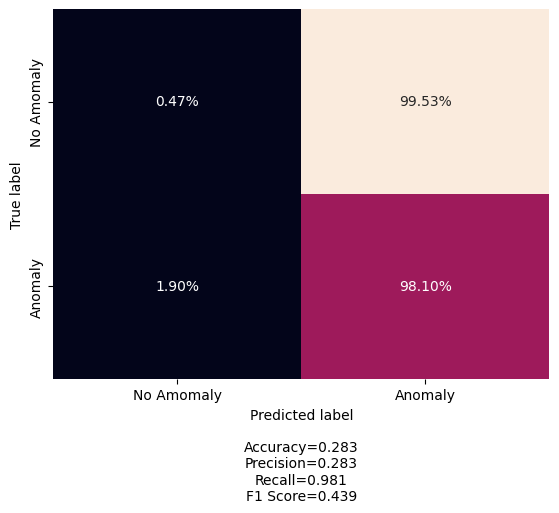

In [14]:
dataframe_data = dataframe_test_scaled.drop(columns=["anomaly", "description"])

plot.make_confusion_matrix(
    format_cf(confusion_matrix(dataframe_test_scaled.anomaly.values, kmeans_custom.predict(dataframe_data.values))),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

In [15]:
# plot.make_confusion_matrix(
#     confusion_matrix(dataframe_train_scaled.anomaly.values, kmeans_custom.labels_),
#     categories=anomaly_names,
#     count=False,
#     cbar=False,
#     figsize=(20, 20)
# )

### Isolation Forest

In [16]:
dataframe_X_train = dataframe_train_scaled.drop(columns=["anomaly", "description"])
dataframe_y_train = dataframe_train_scaled[["anomaly"]]
dataframe_X_test = dataframe_test_scaled.drop(columns=["anomaly", "description"])
dataframe_y_test = dataframe_test_scaled[["anomaly"]]

In [17]:
# dataframe_X = dataframe.drop(columns=["anomaly", "description"])
# dataframe_y = dataframe[["anomaly"]]

# X_train, X_test, y_train, y_test = train_test_split(
#                                                         dataframe_X.values, 
#                                                         dataframe_y.values.ravel(), 
#                                                         test_size=0.3, 
#                                                         random_state=SEED, 
#                                                         stratify=dataframe_y.values.ravel()
# )
# dataframe_X_train = pd.DataFrame(X_train, columns=dataframe_X.columns)
# dataframe_X_test = pd.DataFrame(X_test, columns=dataframe_X.columns)
# dataframe_y_train = pd.DataFrame(y_train, columns=dataframe_y.columns)
# dataframe_y_test = pd.DataFrame(y_test, columns=dataframe_y.columns)

In [18]:
def train_evaluate_isolation_forest(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    contamination: float = 0.01, # Proportion of outliers in the data set
    random_state: int = 42
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Trains and evaluates an Isolation Forest model for anomaly detection.
    """
    print(f"  Training Isolation Forest with contamination={contamination}...")
    model = IsolationForest(contamination=contamination, random_state=random_state, n_jobs=-1)
    model.fit(X_train)

    # Isolation Forest provides a decision_function where lower is more anomalous
    # Convert to a score where higher is more anomalous for consistency
    train_scores = -model.decision_function(X_train)
    test_scores = -model.decision_function(X_test)

    # Predict labels (1 for anomaly, -1 for normal by IsolationForest, convert to 0/1)
    train_labels = (model.predict(X_train) == -1).astype(int)
    test_labels = (model.predict(X_test) == -1).astype(int)

    print(f"  Isolation Forest trained. Detected {np.sum(test_labels)} anomalies in test set.")
    return train_scores, train_labels, test_scores, test_labels

In [19]:
train_scores, train_labels, test_scores, test_labels = train_evaluate_isolation_forest(dataframe_X_train, dataframe_X_test, contamination=0.3, random_state=SEED)

  Training Isolation Forest with contamination=0.3...
  Isolation Forest trained. Detected 5918 anomalies in test set.


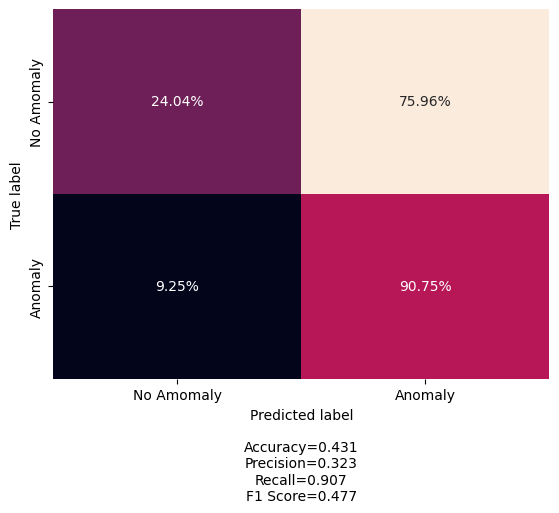

In [20]:
# y = dataframe_y_train.anomaly / dataframe_y_train.anomaly
# y.fillna(0, inplace=True)
# plot.make_confusion_matrix(
#     confusion_matrix(y, train_labels),
#     categories=["No Amomaly", "Anomaly",],
#     count=False,
#     cbar=False,
# )

y = dataframe_y_test.anomaly / dataframe_y_test.anomaly
y.fillna(0, inplace=True)
plot.make_confusion_matrix(
    confusion_matrix(y, test_labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### One Class SVM

In [21]:
def train_evaluate_one_class_svm(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    nu: float = 0.01, # An upper bound on the fraction of training errors and a lower bound of the fraction of support vectors.
    kernel: str = 'rbf',
    gamma: str = 'scale'
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Trains and evaluates a One-Class SVM model for anomaly detection.
    """
    print(f"  Training One-Class SVM with nu={nu}, kernel={kernel}...")
    model = OneClassSVM(nu=nu, kernel=kernel, gamma=gamma)
    model.fit(X_train)

    # One-Class SVM provides a decision_function where higher is more normal
    # Convert to a score where higher is more anomalous for consistency
    train_scores = -model.decision_function(X_train)
    test_scores = -model.decision_function(X_test)

    # Predict labels (1 for normal, -1 for outlier by OCSVM, convert to 0/1)
    train_labels = (model.predict(X_train) == -1).astype(int)
    test_labels = (model.predict(X_test) == -1).astype(int)

    print(f"  One-Class SVM trained. Detected {np.sum(test_labels)} anomalies in test set.")
    return train_scores, train_labels, test_scores, test_labels

In [22]:
train_scores, train_labels, test_scores, test_labels = train_evaluate_one_class_svm(dataframe_X_train, dataframe_X_test)

  Training One-Class SVM with nu=0.01, kernel=rbf...
  One-Class SVM trained. Detected 1026 anomalies in test set.


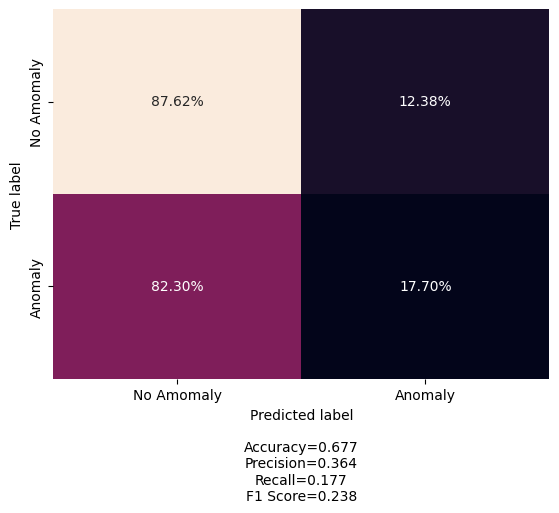

In [23]:
# y = dataframe_y_train.anomaly / dataframe_y_train.anomaly
# y.fillna(0, inplace=True)
# plot.make_confusion_matrix(
#     confusion_matrix(y, train_labels),
#     categories=["No Amomaly", "Anomaly",],
#     count=False,
#     cbar=False,
# )

y = dataframe_y_test.anomaly / dataframe_y_test.anomaly
y.fillna(0, inplace=True)
plot.make_confusion_matrix(
    confusion_matrix(y, test_labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)